In [3]:
import pandas as pd

# Load data
df = pd.read_csv("Sheet1.csv")

# Basic info
print(df.head())
print(df.info())

# Check missing values
print(df.isnull().sum())

# Check duplicates
print(df.duplicated().sum())

   Customer ID  Gender  Age           City Membership Type  Total Spend  \
0          101  Female   29       New York            Gold      1120.20   
1          102    Male   34    Los Angeles          Silver       780.50   
2          103  Female   43        Chicago          Bronze       510.75   
3          104    Male   30  San Francisco            Gold      1480.30   
4          105    Male   27          Miami          Silver       720.40   

   Items Purchased  Average Rating  Discount Applied  \
0               14             4.6              True   
1               11             4.1             False   
2                9             3.4              True   
3               19             4.7             False   
4               13             4.0              True   

   Days Since Last Purchase Satisfaction Level  
0                        25          Satisfied  
1                        18            Neutral  
2                        42        Unsatisfied  
3               

In [4]:
df.describe()

,Customer ID,Age,Total Spend,Items Purchased,Average Rating,Days Since Last Purchase
count,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000
mean,275.500000,33.597143,845.381714,12.600000,4.019143,26.588571
std,101.180532,4.870882,362.058695,4.155984,0.580539,13.440813
min,101.000000,26.000000,410.800000,7.000000,3.000000,9.000000
25%,188.250000,30.000000,502.000000,9.000000,3.500000,15.000000
50%,275.500000,32.500000,775.200000,12.000000,4.100000,23.000000
75%,362.750000,37.000000,1160.600000,15.000000,4.500000,38.000000
max,450.000000,43.000000,1520.100000,21.000000,4.900000,63.000000


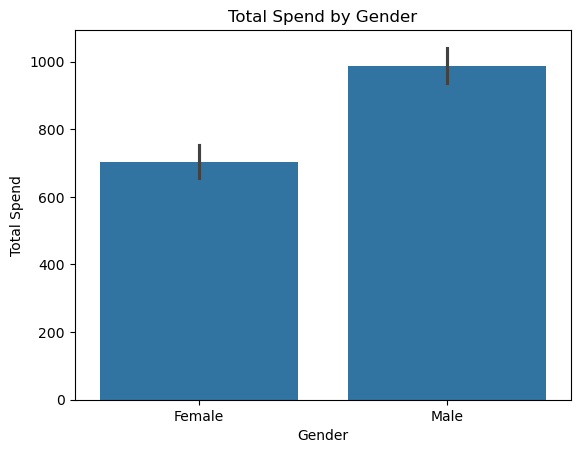

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='Gender', y='Total Spend', data=df)
plt.title("Total Spend by Gender")
plt.show()

>>Male customers have higher total spending compared to female customers.
This indicates that male customers contribute more to overall revenue.
The company can focus on targeted marketing campaigns and premium product offerings for male customers to maximize profits.

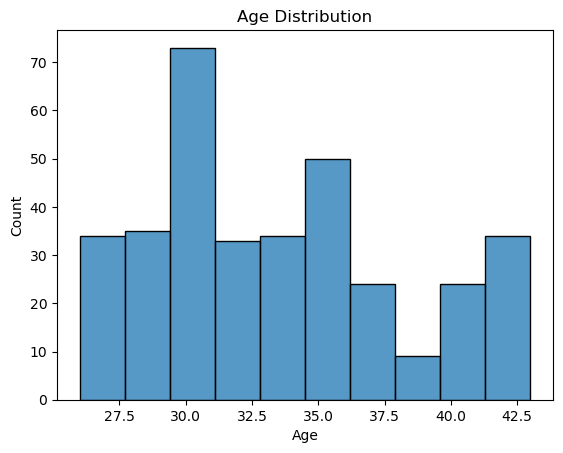

In [7]:
sns.histplot(df['Age'], bins=10)
plt.title("Age Distribution")
plt.show()

>>There is a very clear spike at age 30. More than 70 people in this dataset are 30 years old, making it the most common age group by a significant margin
There is another smaller surge around age 35, where the count reaches 50 people.

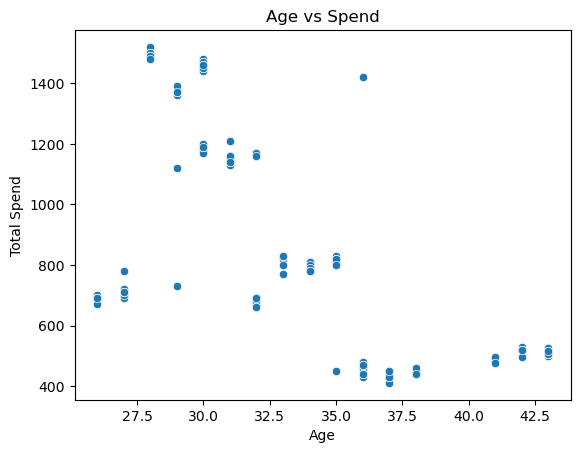

In [8]:
sns.scatterplot(x='Age', y='Total Spend', data=df)
plt.title("Age vs Spend")
plt.show()

>>28–32 year old customers seem willing to spend high amounts regardless of incentives. we should consider shifting discounts away from this peak group and instead use them to "activate" the 35+ or 26–27 groups, who currently have much lower engagement.

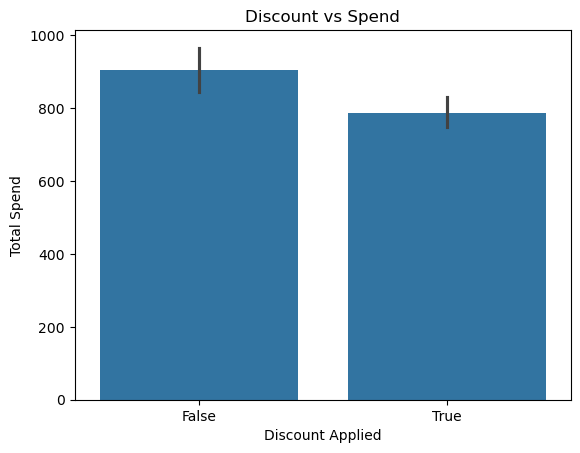

In [9]:
sns.barplot(x='Discount Applied', y='Total Spend', data=df)
plt.title("Discount vs Spend")
plt.show()

>>Most purchases are made without applying discounts.
This suggests that discounts are not the primary driver of customer purchases.
The business can optimize profit margins by limiting unnecessary discounts and offering them only for targeted campaigns.

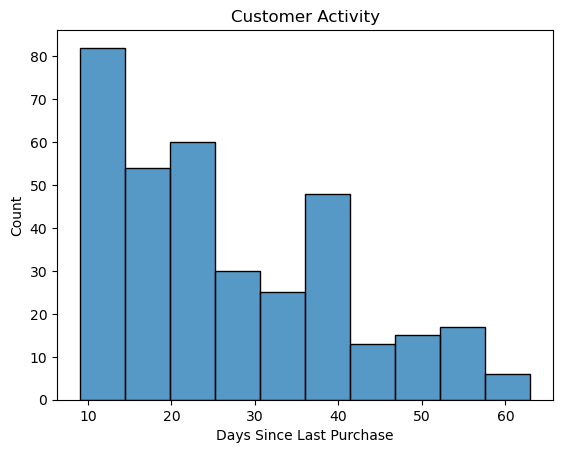

In [10]:
sns.histplot(df['Days Since Last Purchase'], bins=10)
plt.title("Customer Activity")
plt.show()

>>Any customer who has not made a purchase in 40 days should be considered a "high churn risk." This is the perfect time to send a re-engagement email or a "We miss you" discount to prevent them from sliding into that 50+ day inactive zone.

In [13]:
from sklearn.preprocessing import StandardScaler

# Select important columns
data = df[['Total Spend', 'Items Purchased', 'Days Since Last Purchase']]

# Scale data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

In [17]:
import os
os.environ["OMP_NUM_THREADS"] = "2"

In [18]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_data)

E:\Program Files\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


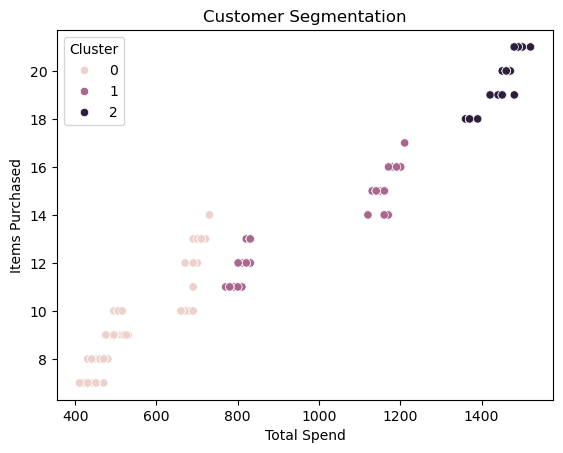

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='Total Spend', y='Items Purchased', hue='Cluster', data=df)
plt.title("Customer Segmentation")
plt.show()

>>Since the "Price per Item" is consistent across all groups, your most effective marketing tools will be volume-based incentives (e.g., "Free shipping over 15 items" or "Bundle discounts") rather than trying to upsell them on individual premium products.

In [21]:
# This tells pandas to ignore text columns and only average the numbers
df.groupby('Cluster').mean(numeric_only=True)

,Customer ID,Age,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase
Cluster,,,,,,,
0,276.097701,35.890805,545.722414,9.540230,3.525862,0.666667,36.241379
1,275.076271,32.415254,985.263559,13.474576,4.358475,0.500000,19.932203
2,274.568966,29.120690,1459.772414,20.000000,4.808621,0.000000,11.172414


>>Segment	        Profile	              Discount Strategy
Cluster 2	 VIPs (Age ~29)	        Do not discount. Use VIP events or early access instead.
Cluster 1	 Growing (Age ~32)	    Targeted upsells. Use "Spend $X more to get 10% off."
Cluster 0	 At-Risk (Age ~36)	    Retention only. Use discounts only to bring them back after 40 days.